<a href="https://colab.research.google.com/github/madhusudhanreddyd-ux/NASCOM_FDP/blob/main/NASSCOM_day_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)

readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


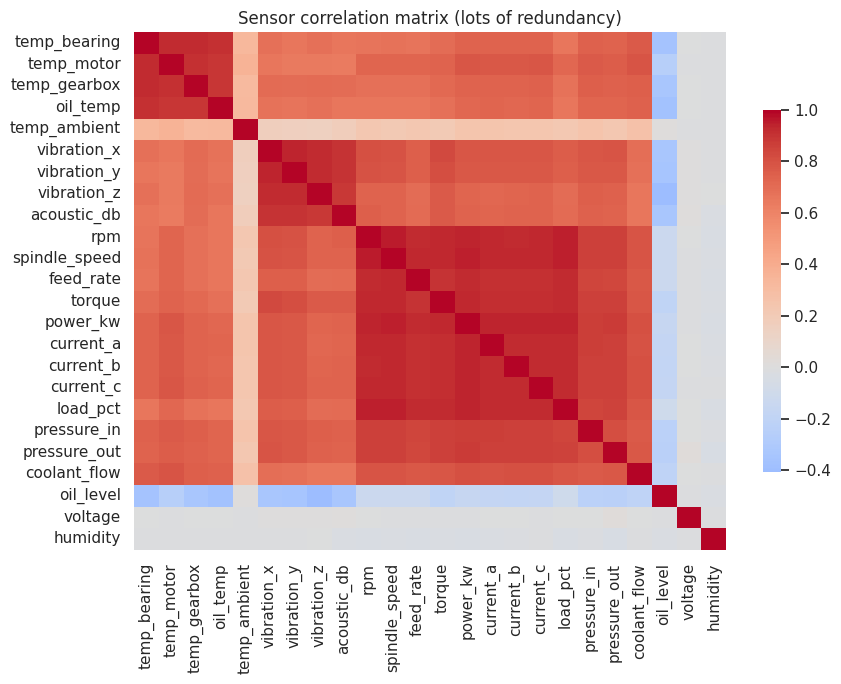

In [3]:

# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [4]:

# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


In [5]:
max_corr_val = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).max().max()
max_corr_pair = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack().idxmax()

print(f"Highest absolute correlation value (excluding diagonal): {max_corr_val:.2f}")
print(f"Sensor pair with highest absolute correlation: {max_corr_pair}")

Highest absolute correlation value (excluding diagonal): 0.95
Sensor pair with highest absolute correlation: ('rpm', 'spindle_speed')


Feeding all 24 sensors directly to a model could cause problems due to **multicollinearity**.

*   **Redundancy**: As shown by the high correlations, many sensors provide similar information. This redundancy doesn't add new insights but can increase model complexity.
*   **Overfitting**: A model might learn to rely on correlated features in ways that don't generalize well to new data, leading to overfitting.
*   **Reduced interpretability**: It becomes harder to understand the individual impact of each sensor on the model's predictions when they are highly correlated.
*   **Computational cost**: More features mean more computational resources and time are needed for training and inference.

In [6]:
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


In [12]:
# 1. drop near-constant
reduced = df[sensors].drop(columns=near_constant)

In [10]:
corr_reduced = reduced.corr().abs()

to_drop_high_corr = set()
# Iterate over the upper triangle of the correlation matrix to find highly correlated pairs
for i in range(len(corr_reduced.columns)):
    for j in range(i + 1, len(corr_reduced.columns)):
        col1 = corr_reduced.columns[i]
        col2 = corr_reduced.columns[j]
        if corr_reduced.loc[col1, col2] > 0.9:
            # Add one of the sensors to the set to be dropped. We can choose col2 for simplicity.
            # Using a set ensures unique entries.
            to_drop_high_corr.add(col2)

print(f"Sensors to drop due to high correlation (>0.9): {list(to_drop_high_corr)}")
reduced_final = reduced.drop(columns=list(to_drop_high_corr))


Sensors to drop due to high correlation (>0.9): ['temp_gearbox', 'vibration_z', 'vibration_y', 'feed_rate', 'power_kw', 'current_a', 'load_pct', 'spindle_speed', 'current_c', 'temp_motor', 'torque', 'acoustic_db', 'current_b', 'oil_temp']


In [11]:
print(f"Number of remaining sensors after reduction: {len(reduced_final.columns)}")
display(reduced_final.head())

Number of remaining sensors after reduction: 8


,temp_bearing,temp_ambient,vibration_x,rpm,pressure_in,pressure_out,coolant_flow,oil_level
0,61.25,25.46,3.07,2125.04,84.58,61.36,27.83,83.31
1,72.66,29.08,2.43,2172.75,90.57,71.68,35.50,77.44
2,65.03,28.65,2.22,2314.11,89.42,64.28,35.80,77.43
3,68.43,25.56,2.74,1589.19,72.74,56.43,27.39,78.13
4,68.64,27.87,3.13,1830.59,79.55,64.78,32.39,78.24


In [13]:

# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


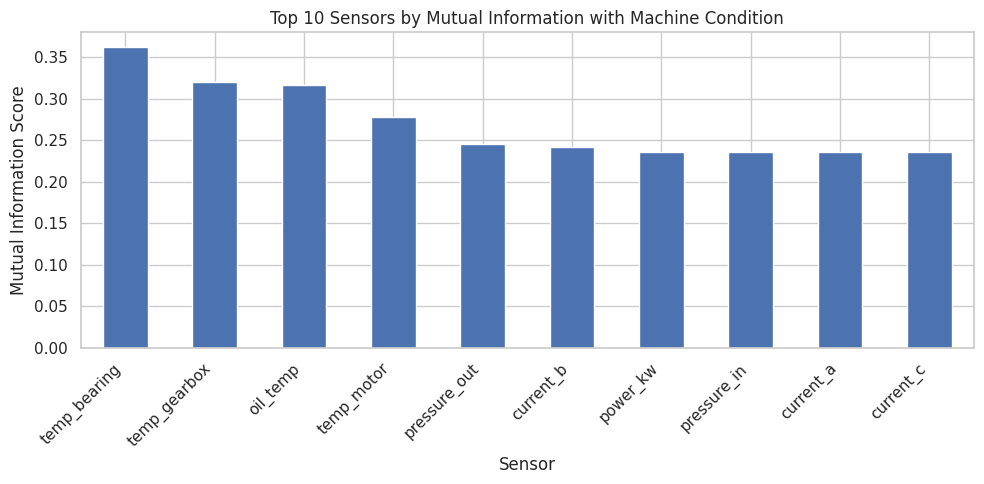

In [20]:
mi.head(10).plot.bar(figsize=(10, 5))
plt.title('Top 10 Sensors by Mutual Information with Machine Condition')
plt.ylabel('Mutual Information Score')
plt.xlabel('Sensor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
top_10_sensors = mi.head(10).index.tolist()
top_10_groups = info[info['sensor'].isin(top_10_sensors)]['group'].value_counts()

print('\nDominant sensor groups among the top 10 MI sensors:')
print(top_10_groups)

# Find the group with the highest count
dominant_group = top_10_groups.idxmax()
print(f"\nThe dominant group is: {dominant_group}")


Dominant sensor groups among the top 10 MI sensors:
group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64

The dominant group is: thermal


In [16]:

# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


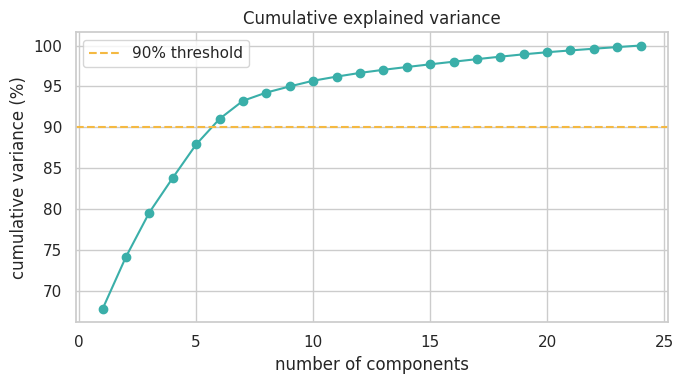

In [17]:

# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

In [22]:
# Find the number of components needed for 90% variance
components_90_variance = np.where(cum >= 0.9)[0][0] + 1
print(f"Number of components needed to explain 90% of the variance: {components_90_variance}")

Number of components needed to explain 90% of the variance: 6


In [23]:
# Report the compression (24 -> ?)
original_sensors = len(sensors)
print(f"Original number of sensors: {original_sensors}")
print(f"Number of components after PCA for 90% variance: {components_90_variance}")
print(f"Compression ratio: {original_sensors} sensors reduced to {components_90_variance} components.")

Original number of sensors: 24
Number of components after PCA for 90% variance: 6
Compression ratio: 24 sensors reduced to 6 components.


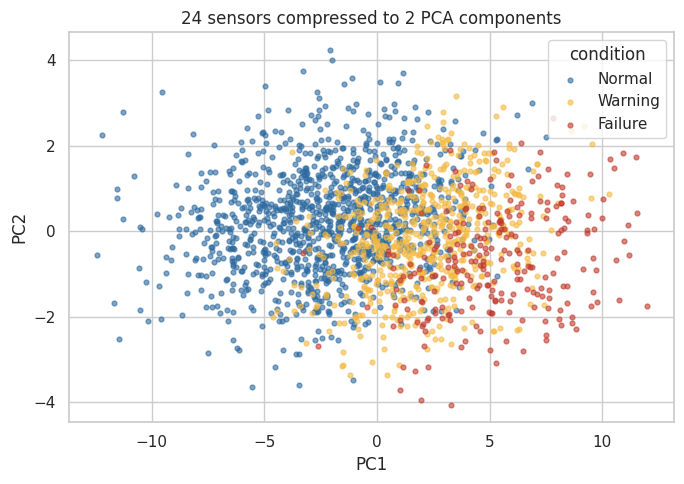

In [25]:
# -----------------------------------------------------------
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

The PCA plot (24 sensors compressed to 2 components) shows a reasonable separation of the machine conditions. The 'Normal' condition data points tend to cluster together, while 'Warning' and 'Failure' conditions show some overlap but generally move towards higher values along both PC1 and PC2. This suggests that these two principal components effectively capture the changes in sensor readings that differentiate the machine's health states.

In [26]:
# Get the loadings for PC1
pc1_loadings = pca.components_[0]

# Create a Pandas Series for easier handling and mapping to sensor names
pc1_loadings_series = pd.Series(pc1_loadings, index=sensors)

# Sort by absolute value to find the most influential sensors (positive or negative loading)
top_3_pc1_sensors = pc1_loadings_series.abs().sort_values(ascending=False).head(3)

print("Top 3 sensors by absolute loading on PC1:")
print(top_3_pc1_sensors)

Top 3 sensors by absolute loading on PC1:
power_kw     0.236235
current_c    0.234338
current_a    0.234046
dtype: float64


In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


### 1. Accuracy vs. Number of PCA Components

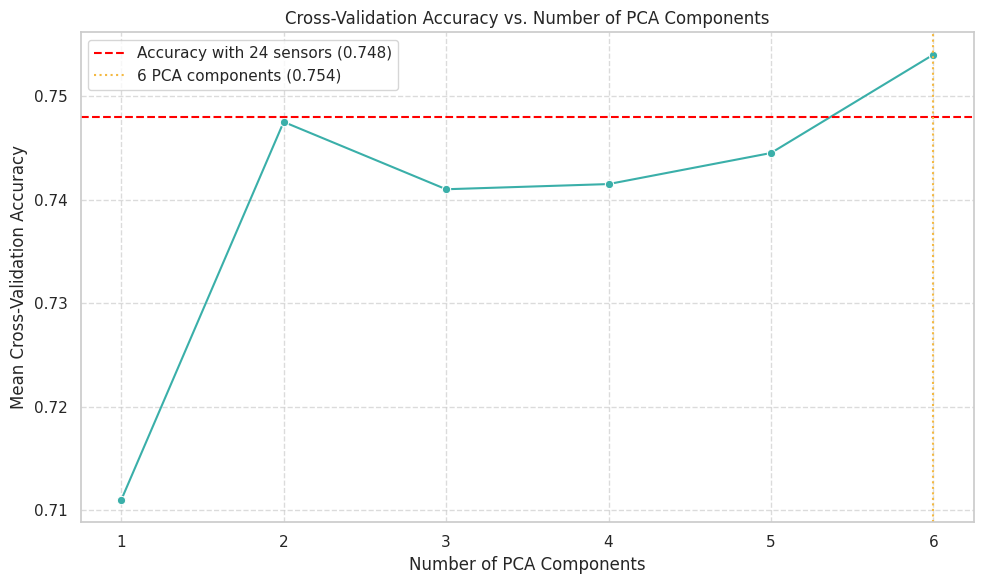

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X (sensor data) and y (condition labels) are already defined from previous cells

accuracies = []
num_components_list = range(1, components_90_variance + 1)

for n in num_components_list:
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=n), LogisticRegression(max_iter=1000))
    score = cross_val_score(pipeline, X, y, cv=5).mean()
    accuracies.append(score)

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame({
    'Number of PCA Components': num_components_list,
    'Accuracy': accuracies
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='Number of PCA Components', y='Accuracy', data=accuracy_df, marker='o', ax=ax, color='#3AAFA9')

# Add a horizontal line for the accuracy with all 24 sensors
ax.axhline(s_full, color='red', linestyle='--', label=f'Accuracy with 24 sensors ({s_full:.3f})')

# Highlight the accuracy with 6 PCA components
ax.axvline(components_90_variance, color='#F4B942', linestyle=':', label=f'{components_90_variance} PCA components ({s_pca:.3f})')

ax.set_title('Cross-Validation Accuracy vs. Number of PCA Components')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Mean Cross-Validation Accuracy')
ax.set_xticks(num_components_list)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Fewest components that match full accuracy:

In [30]:
# Find the minimum number of components that achieve an accuracy >= s_full (accuracy with all 24 sensors)
min_components_for_full_accuracy = None
for n, acc in zip(num_components_list, accuracies):
    if acc >= s_full:
        min_components_for_full_accuracy = n
        break

if min_components_for_full_accuracy is not None:
    print(f"The fewest number of PCA components to achieve an accuracy of at least {s_full:.3f} (accuracy with all 24 sensors) is: {min_components_for_full_accuracy}")
else:
    print(f"Even with {max(num_components_list)} components, the model does not reach the accuracy of {s_full:.3f} achieved with all 24 sensors.")

print(f"Current accuracy with 6 PCA components: {s_pca:.3f}")
print("This shows that a significant reduction in dimensionality can be achieved with minimal or even improved impact on predictive performance.")

The fewest number of PCA components to achieve an accuracy of at least 0.748 (accuracy with all 24 sensors) is: 6
Current accuracy with 6 PCA components: 0.754
This shows that a significant reduction in dimensionality can be achieved with minimal or even improved impact on predictive performance.
